In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

state vector dim = 8
action_space = Box(-1.0, 1.0, (2,), float32) <class 'gymnasium.spaces.box.Box'>


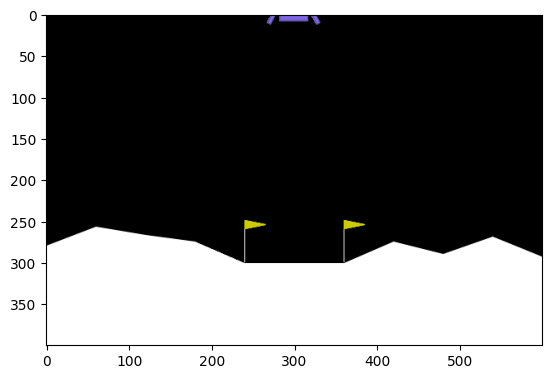

In [2]:
env_id = "LunarLander-v3"
env = gym.make(env_id, render_mode="rgb_array", continuous=True)

env.reset()
action_space = env.action_space
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("action_space =", action_space, type(action_space))

env.close()

In [3]:
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<LunarLander<LunarLander-v3>>>>>

In [4]:
from IPython import display
from IPython.display import clear_output
from sklearn.neural_network import MLPRegressor

In [5]:
def render(env, agent: MLPRegressor, t_max: int = 1_000):
    s, _ = env.reset()
    clear_output(True)
    plt.imshow(env.render())

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:   
        a = agent.predict(s)

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        # a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        plt.imshow(env.render())
        display.display(plt.gcf())
        display.clear_output(wait=True)

        # record sessions like you did before
        s = new_s
        if terminated or truncated:
            break

In [6]:
agent = MLPRegressor(
    hidden_layer_sizes=(50, 50, 50, 30),
    activation="relu",
)

agent = agent.partial_fit([env.reset()[0]], [[0, 0]])

s, _ = env.reset()

res = agent.predict(s.reshape((1, -1)))
print(res)

[[-0.1011294  -0.69698333]]


In [7]:
# render(env, agent, 100)

In [8]:
from gymnasium.spaces.box import Box

def generate_session(env_id: str | gym.Env, agent: MLPRegressor, t_max=1000, train = True, per_sess = 1., per_steps = 0.9):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    if isinstance(env_id, str):
        env = gym.make(env_id, continuous=True)
    else:
        env = env_id
    s, _ = env.reset()

    flag = np.random.rand() > (1 - per_sess)

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:   
        a = agent.predict(s.reshape(1,-1))[0]
        
        if train and flag:
            if np.random.rand() > (1 - per_steps):
                delta = np.random.normal(0, 1/3, size=(2,))
                a += delta
        a = np.clip(a, -1, 1)

        if train and abs(s[3]) < 1e-10:
            a *= 0.

        # print(a.shape)

        # assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        # a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [9]:
dummy_states, dummy_actions, dummy_reward = generate_session(env_id, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 0.00264463  1.4044663   0.26787025 -0.28684017 -0.00305779 -0.06067649
   0.          0.        ]
 [ 0.00515127  1.3978709   0.25258693 -0.2931338  -0.00495877 -0.03802259
   0.          0.        ]
 [ 0.00761127  1.3906698   0.24673557 -0.3200453  -0.00568413 -0.01450898
   0.          0.        ]
 [ 0.00998783  1.3828781   0.23626165 -0.34630245 -0.00430815  0.02752251
   0.          0.        ]
 [ 0.01236429  1.3744861   0.2362571  -0.37297067 -0.00293304  0.02750482
   0.          0.        ]]
actions: [array([ 0.54874416, -0.65703792]), array([-0.2531281 , -0.60614079]), array([-0.61533513, -0.88954111]), array([-0.39960821, -0.40341194]), array([-0.00180523, -1.        ])]
reward: -2.811890147265295


In [10]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    # new_rewards = {val[0]: [] for val in states_batch}
    # ids = {val[0]: [] for val in states_batch}
    # for i, states in enumerate(states_batch):
    #     new_rewards[states[0]].append(rewards_batch[i])
    #     ids[states[0]].append(i)
    # mask = [0] * len(rewards_batch)

    # for st in new_rewards:
    #     reward_threshold = np.percentile(new_rewards[st], q=percentile)
    #     for i, r in enumerate(new_rewards[st]):
    #         if r >= reward_threshold:
    #             mask[ids[st][i]] = 1

    reward_threshold = np.percentile(rewards_batch, q=percentile)
    # for i, r in enumerate(rewards_batch):
    #     if r >= reward_threshold:
    #         mask[i] = 1

    elite_states = []
    elite_actions = []

    for i, r in enumerate(rewards_batch):
        if r > reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions


In [11]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()
    plt.close()


In [12]:
from joblib import Parallel, delayed

In [13]:
def gen_many_sessions(env_id, agent, t_max, cnt, train, per_sess, per_steps):
    return [generate_session(env_id, agent, t_max, train, per_sess, per_steps) for _ in range(cnt)]

In [14]:
def make_sessions(env_id, n_sessions: int, t_max: int, train: bool, per_sess: float, per_steps: float):
    NUM_WORKERS = 50
    results = Parallel(n_jobs=NUM_WORKERS)(
        delayed(gen_many_sessions)(env_id, agent, t_max, n_sessions // NUM_WORKERS, train, per_sess, per_steps)
        for _ in range(NUM_WORKERS)
    )
    ans = []
    for el in results:
        ans.extend(el)
    return ans
    # return results


In [15]:
log = []
buffer = []

In [16]:
def train(n_sessions = 200, percentile = 90, cnt = 500, per_sess = 1, per_steps = 1, train_epoch = 100):
    global buffer
    global log
    for i in range(cnt):
        # generate new sessions
        sessions = make_sessions(env_id, n_sessions, t_max=500, train=True, per_sess=per_sess, per_steps=per_steps)

        all_ses = []
        all_ses.extend(sessions)
        for el in buffer:
            all_ses.extend(el)

        states_batch, actions_batch, rewards_batch = zip(*all_ses)
        # print(sessions)
        # print(states_batch)
        # print(actions_batch)
        # print(rewards_batch)

        elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

        # print(elite_actions)
        # print(elite_states)
        for _ in range(train_epoch):
            agent.partial_fit(elite_states, elite_actions)
        # <YOUR CODE: partial_fit agent to predict elite_actions(y) from elite_states(X)>

        show_progress(
            rewards_batch, log, percentile, reward_range=[np.min(rewards_batch), np.max(rewards_batch)]
        )

        if np.mean(rewards_batch) > 210:
            print("You Win! You may stop training now via KeyboardInterrupt.")
            break
        buffer.append(sessions)
        buffer = buffer[-5:]

        if i % 5 == 0:
            per_sess *= 0.99
            per_steps * 0.999
        # print(len(buffer))
        # print(len(sessions))
        # print(len(all_ses))
        # input()


mean reward = -73.819, threshold=39.017


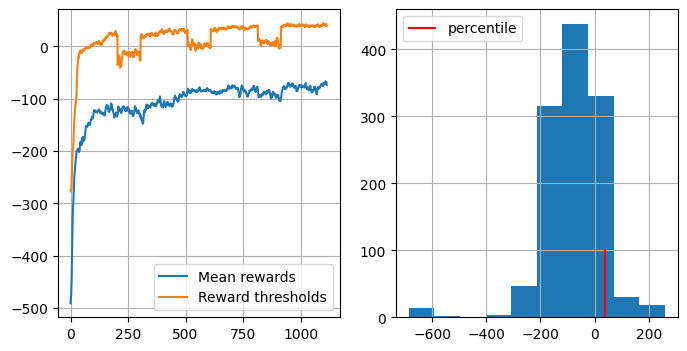

In [31]:
train(200, 90, 200, 0.8, 0.9, 5)

mean reward = -84.434, threshold=39.429


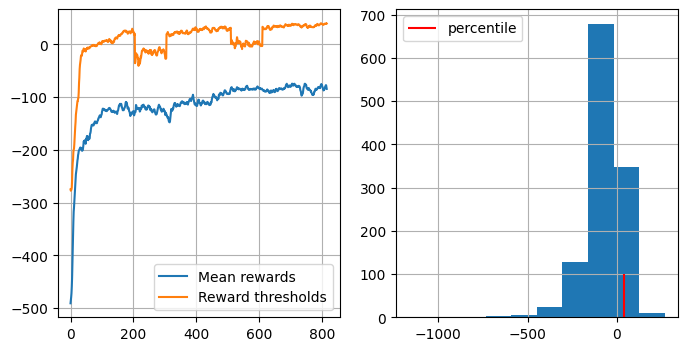

In [29]:
train(200, 90, 5, 0, 0, 100)

mean reward = -102.310, threshold=3.681


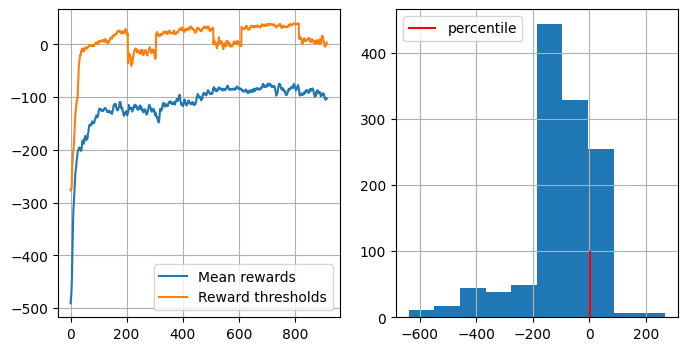

In [30]:
train(200, 80, 100, 0, 0, 10)

In [20]:
from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make(env_id, render_mode="rgb_array", continuous=True),
    video_folder=f"./{env_id}_cont_videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent, t_max=500, train=False) for _ in range(5)]

c:\Users\sapeg\OneDrive\Desktop\SAD_Yandex\RL\Practical_RL\rl-venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\sapeg\OneDrive\Desktop\SAD_Yandex\RL\Practical_RL\week01_intro\LunarLander-v3_cont_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [21]:
def save_agent(agent, path):
    from pickle import dump
    with open(path, 'wb') as f:
        dump(agent, f)

save_agent(agent, 'lunar_lander_agent_cont7.pkl')

In [22]:
def load_agent(path):
    from pickle import load
    with open(path, 'rb') as f:
        return load(f)

In [23]:
model = load_agent('lunar_lander_agent_cont7.pkl')

In [24]:
states_batch, actions_batch, rewards_batch = zip(*make_sessions(env_id, 200, 500, True, 0.5, 0.1))
print(np.mean(rewards_batch))

-128.70500059220817
